In [1]:
import scvi
import pickle
import scanpy as sc
from benchmark_utils import preprocess_scrna, add_cell_types_grouped, create_dirichlet_pseudobulk_dataset

/home/owkin/deepdeconv-fork/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/owkin/deepdeconv-fork/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
genes_path = "project/highest_r2_genes_FACS_1st_gran.pkl"

with open(genes_path, "rb") as f:
    filtered_genes = pickle.load(f)


cti_adata = sc.read("/home/owkin/project/cti/cti_adata.h5ad")
cti_adata = preprocess_scrna(cti_adata, keep_genes=None)
cell_type = f"cell_types_grouped_FACS_1st_level_granularity"
cti_adata, train_test_index = add_cell_types_grouped(cti_adata, "FACS_1st_level_granularity")
cti_adata.obs["cell_types_grouped"] = cti_adata.obs[cell_type]
cti_adata = cti_adata[train_test_index["Train index"]]
cti_adata = cti_adata[:, filtered_genes]

In [4]:
cti_adata.obs.cell_types_grouped.value_counts()

cell_types_grouped
T       91840
B       24648
NK      14746
Mono    12134
DC       1239
Name: count, dtype: int64

In [13]:
cti_adata[cti_adata.obs.cell_types_grouped == "T"].X.toarray().mean(axis=0).mean()

0.35046282

In [14]:
cti_adata[cti_adata.obs.cell_types_grouped == "NK"].X.toarray().mean(axis=0).mean()

0.39099994

In [15]:
cti_adata[cti_adata.obs.cell_types_grouped == "B"].X.toarray().mean(axis=0).mean()

0.34465382

In [16]:
cti_adata[cti_adata.obs.cell_types_grouped == "Mono"].X.toarray().mean(axis=0).mean()

0.5033423

In [17]:
cti_adata[cti_adata.obs.cell_types_grouped == "DC"].X.toarray().mean(axis=0).mean()

0.4345995

In [9]:
cti_adata.X.mean(axis=0).mean()

0.36715582

In [12]:
cti_adata[cti_adata.obs.cell_types_grouped == "T"].X.toarray().std(axis=0).mean()

0.36623138

In [18]:
cti_adata[cti_adata.obs.cell_types_grouped == "NK"].X.toarray().std(axis=0).mean()

0.4021487

In [19]:
cti_adata[cti_adata.obs.cell_types_grouped == "B"].X.toarray().std(axis=0).mean()

0.3741497

In [20]:
cti_adata[cti_adata.obs.cell_types_grouped == "Mono"].X.toarray().std(axis=0).mean()

0.453042

In [21]:
cti_adata[cti_adata.obs.cell_types_grouped == "DC"].X.toarray().std(axis=0).mean()

0.4298597

In [22]:
cti_adata.X.toarray().std(axis=0).mean()

0.45108807

In [3]:
cti_adata

View of AnnData object with n_obs × n_vars = 144607 × 2000
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    uns: 'cell_type_ontology_term_id_colors', 'default_embedding', 'schema_version', 'sex_ontology_term_id_colors', 'title', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'relative_counts'

In [4]:
cti_adata.obs["source"] = "cti"

# !!!!! Here is just a way to initialize those weights responsible for the categorical covariates for the next model

# Change last cell to pseudobulk
cti_adata.obs.iloc[-1, cti_adata.obs.columns.get_loc("source")] = "pseudobulk"

In [5]:
from constants import (
    BATCH_SIZE,
    CAT_COV,
    CHECK_VAL_EVERY_N_EPOCH,
    CONT_COV,
    DISPERSION,
    ENCODE_COVARIATES,
    GENE_LIKELIHOOD,
    LATENT_SIZE,
    LOSS_COMPUTATION,
    MAX_EPOCHS,
    MIXUP_PENALTY,
    N_CELLS_PER_PSEUDOBULK,
    N_HIDDEN,
    N_PSEUDOBULKS,
    PSEUDO_BULK,
    PSEUDO_BULK_AGGREGATION,
    SEED,
    SIGNATURE_TYPE,
    TRAIN_SIZE,
    USE_BATCH_NORM,
)

# scvi.model.SCVI.setup_anndata(
#     cti_adata,
#     layer="counts",
#     categorical_covariate_keys=["source"],
# )

# scvi_model = scvi.model.SCVI(
#     cti_adata,
#     n_latent=LATENT_SIZE,
#     n_hidden=N_HIDDEN,
#     use_batch_norm=USE_BATCH_NORM,
#     dispersion=DISPERSION,
#     gene_likelihood=GENE_LIKELIHOOD,
# )

# scvi_model.view_anndata_setup()

In [6]:
# scvi_model.train(
#     max_epochs=MAX_EPOCHS,
#     batch_size=128,
#     train_size=TRAIN_SIZE,
# )

In [7]:
# scvi_model.save("project/scvi_FACS_1st_gran_base_model")

In [ ]:
model_path = "project/scvi_FACS_1st_gran_base_model"
base_model = scvi.model.SCVI.load(model_path, cti_adata.copy())

INFO     File project/scvi_FACS_1st_gran_base_model/model.pt already downloaded                                    


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [15]:
cti_adata.obsm["latent_sc"] = base_model.get_latent_representation(give_mean = True, return_dist = False)

In [16]:
import numpy as np
import pandas as pd
from anndata import AnnData
from joblib import Parallel, delayed   # optional

def _sample_one_pseudobulk(i, posterior_dirichlet, index_arrays, rel_counts,
                           counts, latent, agg="mean", rng=None):
    """
    Helper: build one pseudobulk and return the aggregated rows.
    """
    rng = np.random.default_rng(rng)          # independent stream

    # --- sample cell indices -------------------------------------------------
    idxs = np.concatenate([
        rng.choice(arr,
                   size=posterior_dirichlet[i, j],
                   replace=posterior_dirichlet[i, j] > arr.size)
        for j, arr in enumerate(index_arrays)
    ])
    # -------------------------------------------------------------------------

    if agg == "mean":
        rc_row = rel_counts[idxs].mean(0)
        c_row  = counts[idxs].mean(0)
        latent_row = latent[idxs].mean(0)
    elif agg == "sum":
        rc_row = rel_counts[idxs].sum(0)
        c_row  = counts[idxs].sum(0)
        latent_row = latent[idxs].sum(0)
    else:
        raise ValueError(f"Unknown aggregation {agg}")

    return rc_row, c_row, latent_row, idxs


def create_dirichlet_pseudobulk_dataset_v2(
    adata: AnnData,
    prior_alphas= None,
    n_sample: int = 300,
    cell_type_group: str = "cell_types_grouped",
    aggregation_method: str = "mean",
    n_cells: int = 256,
    n_jobs: int = 1                          # ← optional parallelism
):
    rng = np.random.default_rng()

    # 1. Dirichlet fractions ➜ integer cell counts per pseudobulk ---------------
    ct_counts = adata.obs[cell_type_group].value_counts()
    ct_names  = ct_counts.index.to_list()

    if prior_alphas is None:
        prior_alphas = np.ones_like(ct_counts, dtype=float)

    post_alpha = prior_alphas + ct_counts / adata.n_obs
    theta      = rng.dirichlet(post_alpha, n_sample)      # (bulk, cell_type)

    if isinstance(n_cells, list):
        n_cells_vec = rng.integers(n_cells[0], n_cells[1], size=n_sample)
        posterior_cn = np.round(theta * n_cells_vec[:, None]).astype(int)
    else:
        posterior_cn = np.round(theta * n_cells).astype(int)

    gt_fractions = posterior_cn / posterior_cn.sum(1, keepdims=True)

    # 2. Pre‑group cell indices once -------------------------------------------
    index_arrays = [
        np.where(adata.obs[cell_type_group].to_numpy() == ct)[0]
        for ct in ct_names
    ]


    # 3. Pull raw matrices (much faster than per‑cell slicing later) ------------
    rel_counts = adata.layers["relative_counts"]      # (scell, gene) Dense / CSR
    counts_mat = adata.layers["counts"]
    latent_mat = adata.obsm["latent_sc"]

    # 4. Build pseudobulks (optionally parallel) --------------------------------
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_sample_one_pseudobulk)(
            i, posterior_cn, index_arrays, rel_counts, counts_mat, latent_mat,
            aggregation_method, rng.bit_generator.random_raw())
        for i in range(n_sample)
    ) if n_jobs != 1 else [
        _sample_one_pseudobulk(
            i, posterior_cn, index_arrays, rel_counts, counts_mat, latent_mat,
            aggregation_method, rng.bit_generator.random_raw())
        for i in range(n_sample)
    ]

    rc_rows, c_rows, latent_rows, all_indices = map(list, zip(*results))

    # 5. Assemble outputs -------------------------------------------------------
    adata_pb_rc = AnnData(
        X=np.vstack(rc_rows),
        var=adata.var.copy(),
        obs=pd.DataFrame(index=[f"PB_{i}" for i in range(n_sample)])
    )
    adata_pb_counts = adata_pb_rc.copy()
    adata_pb_counts.X = np.vstack(c_rows)
    adata_pb_counts.obsm["latent_sc"] = np.vstack(latent_rows)

    df_gt = pd.DataFrame(
        gt_fractions, index=adata_pb_rc.obs_names, columns=ct_names).fillna(0)

    return {
        "adata_pseudobulk_rc":     adata_pb_rc,
        "adata_pseudobulk_counts": adata_pb_counts,
        "all_cell_idx_per_bulk":   all_indices,       # raw indices, very lightweight
        "df_proportions":          df_gt
    }


In [17]:
n_sample = 200

In [12]:
# pseudobulk_adata = create_dirichlet_pseudobulk_dataset(cti_adata, n_sample=n_sample, n_cells=256, cell_type_group="cell_types_grouped", aggregation_method="mean")

In [18]:
pseudobulk_adata_v2 = create_dirichlet_pseudobulk_dataset_v2(cti_adata, n_sample=n_sample, n_cells=256, cell_type_group="cell_types_grouped", aggregation_method="mean", n_jobs=100)

In [14]:
pseudobulk_adata_v2["adata_pseudobulk_counts"]

AnnData object with n_obs × n_vars = 200 × 2000
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    obsm: 'latent_sc'

This is the first draft of the prompt to use to generate the DataLoader:

I want to create a custom dataloader so that I can give to the inference input of the MixUoVAE_v2 in @_mixupvae.py  the precomputed_latent. Consider that ideally the structure of the anndata given to this model is the following:

AnnData object with n_obs × n_vars = 1000 × 2000
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    obsm: 'latent_sc'


Where the latent_sc is the needed precomputed_latent_key

Adding Bulks to the Adata Object that we are going to feed to feed to the MixUpVAE_v2

In [19]:
from benchmark_utils import load_bulk_facs, load_bulk_facs_tpm

In [20]:
genes = pseudobulk_adata_v2["adata_pseudobulk_counts"].var_names.tolist()

In [21]:
bulk_dataset = load_bulk_facs()

bulk_adata = bulk_dataset["dataset"]
bulk_adata = bulk_adata.loc[genes]
bulk_adata = bulk_adata.T

In [91]:
bulk_tpm_dataset = load_bulk_facs_tpm()

bulk_tpm_adata = bulk_tpm_dataset["dataset"]
bulk_tpm_adata = bulk_tpm_adata.loc[genes]
bulk_tpm_adata = bulk_tpm_adata.T

In [18]:
bulk_adata

,ENSG00000085265,ENSG00000105369,ENSG00000038427,ENSG00000090382,ENSG00000170458,ENSG00000156738,ENSG00000011600,ENSG00000171051,ENSG00000121552,ENSG00000163221,...,ENSG00000185650,ENSG00000197971,ENSG00000174837,ENSG00000134369,ENSG00000123600,ENSG00000131236,ENSG00000211640,ENSG00000148450,ENSG00000128524,ENSG00000104043
Sample,,,,,,,,,,,,,,,,,,,,,
3003,43412.155784,747.490566,67752.507498,120620.231199,8484.005591,2351.395643,4059.888884,4462.376338,1000.003469,1828.069946,...,5353.649276,3852.731633,1003.672035,586.721243,503.098059,10484.632202,7.476072,172.419239,658.246038,453.497237
4015,15602.617892,1179.056370,13368.734667,15372.916180,1028.568908,5758.361225,1429.486862,574.120554,382.590488,524.672012,...,3908.526729,2531.292183,443.180302,234.164852,541.648978,5952.428533,6.455029,113.206513,315.644444,331.609655
5003,21365.341786,1461.662977,24654.894610,72780.384942,2717.282032,7020.355746,1902.162456,1519.765321,643.785822,1054.224457,...,7258.003915,3396.623065,647.775049,369.005500,468.588841,8270.293947,19.812868,151.332784,447.542502,255.919068
6011,25986.503125,1327.682873,49929.810183,73015.789733,3963.431088,4703.551693,2837.126662,4178.135759,1185.020524,2538.910721,...,3787.549981,3549.768312,430.891936,463.666995,402.444177,9863.370212,91.666428,168.821569,646.644657,600.288238
6013,14481.001022,4800.626740,19713.747081,33480.546160,1929.075486,19761.971031,1474.177023,2049.936381,691.891831,1543.706656,...,3550.304308,2102.854404,282.298867,248.444341,383.581989,7074.896324,125.682104,73.152364,496.235065,586.951686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20004,14048.207257,1064.328882,13752.635650,23985.991023,3055.263965,2723.090690,2083.964960,845.261144,381.817035,455.313163,...,3420.915475,1957.544690,479.765911,144.796740,161.707235,4637.521143,23.458611,84.218931,399.497205,133.486857
20005,10340.102803,945.055371,9429.890524,15657.608813,1365.092278,3559.413278,1317.223553,655.573218,226.403912,270.889920,...,2603.859439,1997.006969,267.927342,237.770990,308.103546,3951.370038,10.701229,38.954419,315.186617,149.850311
21002,20126.676388,930.519926,18977.281796,36125.993877,3713.322065,2614.332199,2043.611458,1683.316327,486.611724,950.487239,...,3280.183884,2053.736961,411.865163,148.775120,289.074804,5393.848912,14.654324,87.343209,396.792541,159.995962


In [93]:
bulk_tpm_adata

,ENSG00000085265,ENSG00000105369,ENSG00000038427,ENSG00000090382,ENSG00000170458,ENSG00000156738,ENSG00000011600,ENSG00000171051,ENSG00000121552,ENSG00000163221,...,ENSG00000185650,ENSG00000197971,ENSG00000174837,ENSG00000134369,ENSG00000123600,ENSG00000131236,ENSG00000211640,ENSG00000148450,ENSG00000128524,ENSG00000104043
Sample,,,,,,,,,,,,,,,,,,,,,
3003,15.405768,9.547482,16.047649,16.879766,13.296463,11.199556,11.987221,12.123561,9.966873,10.836536,...,12.386218,11.911682,9.972151,9.147245,8.977203,13.355768,3.083079,7.437764,9.364315,8.827770
4015,13.927871,10.204320,13.706363,13.907877,10.350246,12.491373,10.481971,9.167401,8.583104,9.037700,...,11.932458,11.305908,8.794682,8.079876,9.083556,12.539185,2.897937,6.835184,8.306401,8.377367
5003,14.381406,10.514137,14.589400,16.151037,11.626146,12.777289,10.893938,10.570337,9.332431,10.043089,...,12.825311,11.730065,9.341330,8.302654,8.875010,13.013652,4.379171,7.250839,8.808856,8.004926
6011,14.665541,10.375670,15.607531,16.155829,12.196946,12.199730,11.470612,12.028878,10.211802,11.310451,...,11.887319,11.793804,8.754416,9.119619,8.656114,13.267900,6.533865,7.407765,9.338948,9.231802
6013,13.820173,12.228909,14.266589,15.030680,11.163559,14.270113,10.526274,11.001668,9.436088,10.592719,...,11.793735,11.038421,8.145784,7.973164,8.586750,12.788298,6.984673,6.212027,8.957386,9.199156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20004,13.775712,10.055996,13.746438,14.548877,11.857404,11.410472,11.024720,9.723873,8.579426,8.832795,...,11.739501,10.934479,8.908105,7.092129,7.345053,12.178362,4.611227,6.412027,8.644563,7.070242
20005,13.334247,9.885328,13.202725,13.934215,10.651071,11.797375,10.363926,9.358359,7.828662,8.086427,...,11.346536,10.963892,8.070621,7.670897,8.271494,11.948049,3.548173,5.319841,8.304180,7.236523
21002,14.297328,9.862862,14.211480,15.140208,12.129874,11.352197,10.997030,10.717366,8.929009,9.893460,...,11.679420,11.004157,8.688947,7.462758,8.179702,12.396786,3.967945,6.464473,8.635292,7.330303


In [94]:
pseudobulk_adata_v2["adata_pseudobulk_counts"]

AnnData object with n_obs × n_vars = 10000 × 2000
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    obsm: 'latent_sc'

In [95]:
pseudobulk_adata_v2["adata_pseudobulk_counts"].var

,gene_symbols,feature_is_filtered,feature_name,feature_reference,feature_biotype,n_counts
gene_ids,,,,,,
ENSG00000085265,FCN1,False,FCN1,NCBITaxon:9606,gene,282991.0
ENSG00000105369,CD79A,False,CD79A,NCBITaxon:9606,gene,425621.0
ENSG00000038427,VCAN,False,VCAN,NCBITaxon:9606,gene,545282.0
ENSG00000090382,LYZ,False,LYZ,NCBITaxon:9606,gene,2944313.0
ENSG00000170458,CD14,False,CD14,NCBITaxon:9606,gene,246112.0
...,...,...,...,...,...,...
ENSG00000131236,CAP1,False,CAP1,NCBITaxon:9606,gene,535000.0
ENSG00000211640,IGLV6-57,False,IGLV6-57,NCBITaxon:9606,gene,286991.0
ENSG00000148450,MSRB2,False,MSRB2,NCBITaxon:9606,gene,47651.0


In [96]:
pseudobulk_adata_v2["df_proportions"]

,T,B,NK,Mono,DC
PB_0,0.191406,0.210938,0.050781,0.242188,0.304688
PB_1,0.333333,0.380392,0.070588,0.125490,0.090196
PB_2,0.308594,0.062500,0.105469,0.433594,0.089844
PB_3,0.315175,0.182879,0.050584,0.159533,0.291829
PB_4,0.085603,0.548638,0.151751,0.140078,0.073930
...,...,...,...,...,...
PB_9995,0.019531,0.015625,0.875000,0.007812,0.082031
PB_9996,0.523438,0.109375,0.031250,0.281250,0.054688
PB_9997,0.478431,0.054902,0.211765,0.015686,0.239216
PB_9998,0.381323,0.015564,0.027237,0.428016,0.147860


In [97]:
pseudobulk_adata_v2["df_proportions"].sum(axis=1)

PB_0       1.0
PB_1       1.0
PB_2       1.0
PB_3       1.0
PB_4       1.0
          ... 
PB_9995    1.0
PB_9996    1.0
PB_9997    1.0
PB_9998    1.0
PB_9999    1.0
Length: 10000, dtype: float64

In [22]:
bulk_adata = AnnData(
    X=bulk_adata.values,
    var= pseudobulk_adata_v2["adata_pseudobulk_counts"].var,
)

In [23]:
bulk_dataset["ground_truth"] = bulk_dataset["ground_truth"]/100

In [24]:
bulk_dataset["ground_truth"] = bulk_dataset["ground_truth"].div(bulk_dataset["ground_truth"].sum(axis=1), axis=0)

In [25]:
bulk_dataset["ground_truth"]= bulk_dataset["ground_truth"][pseudobulk_adata_v2["df_proportions"].columns]

In [26]:
bulk_adata.obsm["latent_sc"] = np.full(
    (bulk_adata.n_obs, pseudobulk_adata_v2["adata_pseudobulk_counts"].obsm["latent_sc"].shape[1]),
    np.nan,
    dtype=np.float32
)

In [27]:
bulk_dataset["ground_truth"].reset_index(drop=True)

,T,B,NK,Mono,DC
0,0.344904,0.071577,0.042798,0.534008,0.006713
1,0.672912,0.214870,0.039983,0.060049,0.012186
2,0.548288,0.250383,0.041310,0.146947,0.013072
3,0.243670,0.335200,0.076460,0.342971,0.001699
4,0.100784,0.785835,0.009010,0.098402,0.005969
...,...,...,...,...,...
201,0.139022,0.226802,0.198451,0.407078,0.028647
202,0.449221,0.161468,0.142947,0.236164,0.010200
203,0.415791,0.149436,0.089600,0.333871,0.011302
204,0.407138,0.089214,0.175221,0.313769,0.014658


In [28]:
bulk_adata.obsm["ground_truth"] = bulk_dataset["ground_truth"].values

In [26]:
bulk_adata.obsm["ground_truth"]

array([[0.34490432, 0.07157692, 0.0427978 , 0.53400831, 0.00671265],
       [0.67291242, 0.21487   , 0.03998278, 0.06004904, 0.01218576],
       [0.54828828, 0.2503829 , 0.04130983, 0.14694652, 0.01307246],
       ...,
       [0.41579128, 0.14943599, 0.08959954, 0.33387075, 0.01130244],
       [0.40713814, 0.08921361, 0.17522069, 0.31376912, 0.01465844],
       [0.28674762, 0.07608781, 0.16081469, 0.45908576, 0.01726412]])

In [29]:
bulk_adata.uns["cell_types_order"] = bulk_dataset["ground_truth"].columns.tolist()

In [28]:
bulk_adata.uns["cell_types_order"]

['T', 'B', 'NK', 'Mono', 'DC']

In [30]:
bulk_adata.obs["has_latent"] = False
pseudobulk_adata_v2["adata_pseudobulk_counts"].obs["has_latent"] = True

In [31]:
pseudobulk_adata_v2["adata_pseudobulk_counts"].obsm["ground_truth"] = pseudobulk_adata_v2["df_proportions"].values
pseudobulk_adata_v2["adata_pseudobulk_counts"].uns["cell_type_names"] = pseudobulk_adata_v2["df_proportions"].columns

In [32]:
import anndata as ad 
adata = ad.concat(
    [pseudobulk_adata_v2["adata_pseudobulk_counts"], bulk_adata],
    join="outer",
    merge="same",
    label="source",
    keys=["pseudobulk", "bulk"])

In [32]:
adata

AnnData object with n_obs × n_vars = 406 × 2000
    obs: 'has_latent', 'source'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    obsm: 'latent_sc', 'ground_truth'

In [33]:
adata.obsm["ground_truth"]

array([[0.70038911, 0.07392996, 0.06614786, 0.02723735, 0.13229572],
       [0.14117647, 0.00784314, 0.22745098, 0.55294118, 0.07058824],
       [0.3125    , 0.1171875 , 0.2578125 , 0.046875  , 0.265625  ],
       ...,
       [0.41579128, 0.14943599, 0.08959954, 0.33387075, 0.01130244],
       [0.40713814, 0.08921361, 0.17522069, 0.31376912, 0.01465844],
       [0.28674762, 0.07608781, 0.16081469, 0.45908576, 0.01726412]])

In [34]:
cti_adata

AnnData object with n_obs × n_vars = 144607 × 2000
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped', 'source'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    uns: 'cell_type_ontology_term_id_colors', 'default_embedding', 'schema_version', 'sex_ontology_term_id_colors', 'title', 'log1p'
    obsm: 'X_umap', 'latent_sc'
    layers: 'counts', 'relative_counts'

In [35]:
from benchmark_utils.latent_signature_utils import create_latent_signature
latent_signature_matrix = create_latent_signature(
    cti_adata,
    model=scvi_model,
    use_mixupvi=False,
    average_all_cells=True,
)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [36]:
bulk_adata.uns["cell_types_order"]

['T', 'B', 'NK', 'Mono', 'DC']

In [37]:
# Reorder latent signature matrix according to cell types order
ordered_indices = [np.where(latent_signature_matrix.obs["cell type"] == cell_type)[0][0] for cell_type in bulk_adata.uns["cell_types_order"]]

In [38]:
ordered_latent_signature = latent_signature_matrix.X[ordered_indices]

In [39]:
adata.uns["latent_signature_matrix"] = ordered_latent_signature

In [119]:
from scvi.model import MixUpVI_v2
MixUpVI_v2.setup_anndata(
    adata,
    categorical_covariate_keys=["source"],
)


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [120]:
adata

AnnData object with n_obs × n_vars = 10206 × 2000
    obs: 'has_latent', 'source', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    uns: 'latent_signature_matrix', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'latent_sc', 'ground_truth', '_scvi_extra_categorical_covs'

In [121]:
adata.obs

,has_latent,source,_scvi_batch,_scvi_labels
PB_0,True,pseudobulk,0,0
PB_1,True,pseudobulk,0,0
PB_2,True,pseudobulk,0,0
PB_3,True,pseudobulk,0,0
PB_4,True,pseudobulk,0,0
...,...,...,...,...
201,False,bulk,0,0
202,False,bulk,0,0
203,False,bulk,0,0
204,False,bulk,0,0


In [122]:
new_model = scvi.model.MixUpVI_v2(
    adata,
    **scvi_model.init_params_["non_kwargs"],
    **scvi_model.init_params_["kwargs"]["model_kwargs"],
    latent_signature_matrix = latent_signature_matrix.X,
)

In [123]:
new_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.0.

Setup via `MixUpVI_v2.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['source'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 10206 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│      n_ground_truth      │   5   │
│         n_labels         │   1   │
│       n_latent_sc        │  10   │
│          n_vars          │ 2000  │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│      ground_truth      │         adata.obsm['ground_truth']         │
│         labels         │         adata.obs['_scvi_labels']          │
│       latent_sc        │          adata.obsm['latent_sc']           │
└────────────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['source'] │ pseudobulk │          0          │
│                     │    bulk    │          1          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

In [124]:
from scvi.data import AnnDataManager
from scvi.dataloaders import AnnDataLoader
from scvi.dataloaders._data_splitting import validate_data_split
from typing import Optional
from scvi import settings
import logging
import lightning.pytorch as pl


logger = logging.getLogger(__name__)


class MixUpV2DataSplitter(pl.LightningDataModule):

    data_loader_cls = AnnDataLoader
    
    def __init__(
            self,
            adata_manager: AnnDataManager,
            train_size: float = 0.9,
            validation_size: Optional[float] = None,
            shuffle_set_split: bool = True,
            pin_memory: bool = False,
            **kwargs,
    ):
        super().__init__()
        self.adata_manager = adata_manager
        self.train_size = train_size
        self.validation_size = validation_size
        self.shuffle_set_split = shuffle_set_split
        self.data_loader_kwargs = kwargs
        self.pin_memory = pin_memory or settings.dl_pin_memory_gpu_training

        try:
            self.n_samples_pseudobulk = self.adata_manager.adata.obs["source"].value_counts()["pseudobulk"]
            self.n_samples_bulk = self.adata_manager.adata.obs["source"].value_counts()["bulk"]
        except KeyError as e:
            logger.error("You should not use this datasplitter if you are not training the MixUpV2 model!")
            raise e

        self.n_train_pseudobulk, self.n_val_pseudobulk = validate_data_split(
            n_samples=self.n_samples_pseudobulk,
            train_size=self.train_size,
            validation_size=self.validation_size,
        )
        
        self.n_train_bulk, self.n_val_bulk = validate_data_split(
            n_samples=self.n_samples_bulk,
            train_size=self.train_size,
            validation_size=self.validation_size,
        )

        self.n_train = self.n_train_pseudobulk + self.n_train_bulk
        self.n_val = self.n_val_pseudobulk + self.n_val_bulk

        if self.adata_manager.adata.n_obs != self.n_train + self.n_val:
            logger.warning(f"Number of samples in adata: {self.adata_manager.adata.n_obs} is not equal to the sum of the number of samples in pseudobulk and bulk: {self.n_train + self.n_val}")


    def setup(self, batch_bulk_proportion: float = 0.1, stage: Optional[str] = None):
        n_train_pseudobulk = self.n_train_pseudobulk
        n_val_pseudobulk = self.n_val_pseudobulk
        n_train_bulk = self.n_train_bulk
        n_val_bulk = self.n_val_bulk
        
        indices_pseudobulk = list(np.where(self.adata_manager.adata.obs["source"] == "pseudobulk")[0])
        indices_bulk = list(np.where(self.adata_manager.adata.obs["source"] == "bulk")[0])

        if self.shuffle_set_split:
            random_state = np.random.RandomState(seed=settings.seed)
            indices_pseudobulk = random_state.permutation(indices_pseudobulk)
            indices_bulk = random_state.permutation(indices_bulk)

        self.pseudobulks_val_idx = list(indices_pseudobulk[:n_val_pseudobulk])
        self.pseudobulks_train_idx = list(indices_pseudobulk[n_val_pseudobulk : (n_val_pseudobulk + n_train_pseudobulk)])
        self.pseudobulks_test_idx = list(indices_pseudobulk[(n_val_pseudobulk + n_train_pseudobulk) :])

        self.bulk_val_idx = list(indices_bulk[:n_val_bulk])
        self.bulk_train_idx = list(indices_bulk[n_val_bulk : (n_val_bulk + n_train_bulk)])
        self.bulk_test_idx = list(indices_bulk[(n_val_bulk + n_train_bulk) :])

        self.val_idx = self.pseudobulks_val_idx + self.bulk_val_idx
        self.test_idx = self.pseudobulks_test_idx + self.bulk_test_idx

        batch_size = self.data_loader_kwargs["batch_size"]
        # Calculate number of bulks and pseudobulks per batch based on proportion
        n_bulks_per_batch = int(batch_size * batch_bulk_proportion)
        n_pseudobulks_per_batch = batch_size - n_bulks_per_batch

        # Calculate number of complete batches and remaining samples
        n_complete_batches = len(self.pseudobulks_train_idx) // n_pseudobulks_per_batch
        
        # Initialize empty train indices list
        self.train_idx = []
        
        # For each complete batch
        for i in range(n_complete_batches):
            # Get pseudobulk indices for this batch
            start_idx = i * n_pseudobulks_per_batch
            end_idx = start_idx + n_pseudobulks_per_batch
            batch_pseudobulks = self.pseudobulks_train_idx[start_idx:end_idx]
            
            # Sample bulk indices with replacement to match desired proportion
            batch_bulks = np.random.choice(
                self.bulk_train_idx,
                size=n_bulks_per_batch,
                replace=True
            )
            
            # Combine and shuffle indices for this batch
            batch_indices = list(batch_pseudobulks) + list(batch_bulks)
            np.random.shuffle(batch_indices)
            self.train_idx.extend(batch_indices)
            
        # Handle remaining pseudobulk samples in a partial batch if any exist
        remaining_pseudobulks = self.pseudobulks_train_idx[n_complete_batches * n_pseudobulks_per_batch:]
        if len(remaining_pseudobulks) > 0:
            # Calculate proportional number of bulks for partial batch
            n_remaining_bulks = int(np.ceil(len(remaining_pseudobulks) * batch_bulk_proportion / (1 - batch_bulk_proportion)))
            
            # Sample bulk indices for partial batch
            remaining_bulks = np.random.choice(
                self.bulk_train_idx,
                size=n_remaining_bulks,
                replace=True
            )
            
            # Add final partial batch
            final_batch = list(remaining_pseudobulks) + list(remaining_bulks)
            np.random.shuffle(final_batch)
            self.train_idx.extend(final_batch)


    def train_dataloader(self):
        return self.data_loader_cls(
            self.adata_manager,
            indices=self.train_idx,
            shuffle=False,
            drop_last=False,
            pin_memory=self.pin_memory,
            **self.data_loader_kwargs,
        )
    
    def val_dataloader(self):
        return self.data_loader_cls(
            self.adata_manager,
            indices=self.val_idx,
            shuffle=False,
            drop_last=False,
            pin_memory=self.pin_memory,
            **self.data_loader_kwargs,
        )
    
    def test_dataloader(self):
        return self.data_loader_cls(
            self.adata_manager,
            indices=self.test_idx,
            shuffle=False,
            drop_last=False,
            pin_memory=self.pin_memory,
            **self.data_loader_kwargs,
        )

In [125]:
new_model.adata_manager.data_registry

X:
  attr_key: null
  attr_name: X
batch:
  attr_key: _scvi_batch
  attr_name: obs
extra_categorical_covs:
  attr_key: _scvi_extra_categorical_covs
  attr_name: obsm
ground_truth:
  attr_key: ground_truth
  attr_name: obsm
labels:
  attr_key: _scvi_labels
  attr_name: obs
latent_sc:
  attr_key: latent_sc
  attr_name: obsm

In [126]:
from scvi.data.fields import ObsmField, StringUnsField
new_model.adata_manager.register_new_fields(
    [
        ObsmField(
            registry_key="latent_sc",
            attr_key="latent_sc",
        ),
        ObsmField(
            registry_key="ground_truth",
            attr_key="ground_truth",
        ),
    ]
)
new_model.adata_manager.data_registry

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


X:
  attr_key: null
  attr_name: X
batch:
  attr_key: _scvi_batch
  attr_name: obs
extra_categorical_covs:
  attr_key: _scvi_extra_categorical_covs
  attr_name: obsm
ground_truth:
  attr_key: ground_truth
  attr_name: obsm
labels:
  attr_key: _scvi_labels
  attr_name: obs
latent_sc:
  attr_key: latent_sc
  attr_name: obsm

In [127]:
new_data_splitter = MixUpV2DataSplitter(
    adata_manager=new_model.adata_manager,
    train_size=0.9,
    validation_size=0.1,
    batch_size=256,
)

In [128]:
new_data_splitter.setup()

In [129]:
train_dl = new_data_splitter.train_dataloader()

for batch in train_dl:
    print(batch.keys())
    break

dict_keys(['X', 'batch', 'extra_categorical_covs', 'ground_truth', 'labels', 'latent_sc'])


In [130]:
for batch in train_dl:
    print(batch["latent_sc"].shape)
    break

torch.Size([256, 10])


In [131]:
import torch
# Count rows with nans
nan_rows = torch.isnan(batch["latent_sc"]).any(dim=1).sum()
print(f"Number of rows containing NaN values: {nan_rows}")

Number of rows containing NaN values: 25


In [132]:
batch.keys()

dict_keys(['X', 'batch', 'extra_categorical_covs', 'ground_truth', 'labels', 'latent_sc'])

In [133]:
batch["latent_sc"][batch["extra_categorical_covs"][:, 0] == 0.0].shape

torch.Size([231, 10])

In [134]:
batch["X"][batch["extra_categorical_covs"][:, 0] == 0.0]

tensor([[1.3867, 2.4258, 1.9375,  ..., 0.1211, 1.2344, 0.0820],
        [3.0273, 0.3828, 4.7461,  ..., 0.1641, 1.3164, 0.0781],
        [0.7812, 0.8594, 1.2070,  ..., 0.0820, 0.6836, 0.0352],
        ...,
        [1.8047, 0.5039, 3.8750,  ..., 0.0977, 0.8164, 0.0742],
        [0.8984, 3.5586, 1.1914,  ..., 0.1055, 0.9102, 0.0859],
        [5.9961, 0.7098, 9.9843,  ..., 0.2314, 1.3843, 0.0941]])

In [135]:
batch["X"][batch["extra_categorical_covs"][:, 0] == 1.0]

tensor([[17925.0039,   871.8852, 20025.4199,  ...,    74.9870,   487.5476,
           387.1753],
        [23626.7520,  1885.6165, 20764.8125,  ...,   105.9244,   483.6566,
           330.9327],
        [18687.1543,  2252.4507, 15279.3086,  ...,   163.3595,   649.3365,
           271.4929],
        ...,
        [11074.2480,   654.8462, 18201.0039,  ...,    80.5324,   597.6487,
           367.4843],
        [36770.7188,   563.7922, 25411.3711,  ...,   206.4567,   676.4792,
           431.4314],
        [14613.1504,  1920.4008, 12282.8887,  ...,    91.0967,   443.7674,
           264.0912]])

In [136]:
batch["ground_truth"]

tensor([[0.0703, 0.3242, 0.2734, 0.0703, 0.2617],
        [0.2734, 0.0352, 0.2188, 0.3008, 0.1719],
        [0.6328, 0.1250, 0.0938, 0.0703, 0.0781],
        ...,
        [0.4961, 0.0898, 0.1836, 0.2109, 0.0195],
        [0.2773, 0.4570, 0.0117, 0.0547, 0.1992],
        [0.2157, 0.0902, 0.1020, 0.5804, 0.0118]])

In [137]:
adata

AnnData object with n_obs × n_vars = 10206 × 2000
    obs: 'has_latent', 'source', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts'
    uns: 'latent_signature_matrix', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'latent_sc', 'ground_truth', '_scvi_extra_categorical_covs'

In [138]:
batch["extra_categorical_covs"].bool().squeeze()

tensor([False, False, False,  True, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False,
        False, False,  True, False, False, False,  True, False, False, False,
         True, False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,  True,
        False,  True,  True, False, False, False, False, False, False, False,
        False, False,  True, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True, False,  True, False, False, 

In [139]:
batch.keys()

dict_keys(['X', 'batch', 'extra_categorical_covs', 'ground_truth', 'labels', 'latent_sc'])

In [140]:
scvi_model.init_params_

{'kwargs': {'model_kwargs': {'use_batch_norm': 'none'}},
 'non_kwargs': {'n_hidden': 512,
  'n_latent': 10,
  'n_layers': 1,
  'dropout_rate': 0.1,
  'dispersion': 'gene',
  'gene_likelihood': 'zinb',
  'latent_distribution': 'normal'}}

In [141]:
latent_signature_matrix.shape

(5, 10)

In [142]:
from benchmark_utils._init_utils import transfer_weights_selective

transfer_weights_selective(scvi_model, new_model)

Weight transfer completed (non-strict mode)


In [143]:
new_model.train(
    max_epochs=MAX_EPOCHS,
    batch_size=256,
    train_size=TRAIN_SIZE,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 100/100: 100%|██████████| 100/100 [11:51<00:00,  7.05s/it, v_num=1, train_loss_step=1.92e+3, train_loss_epoch=1.72e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [11:51<00:00,  7.12s/it, v_num=1, train_loss_step=1.92e+3, train_loss_epoch=1.72e+3]


In [144]:
new_model.save("project/mixupvi_v2_FACS_1st_gran")

# Analysing the latent space for the new 2-networks structure

In [42]:
import scvi
new_model = scvi.model.MixUpVI_v2.load("project/mixupvi_v2_FACS_1st_gran", adata.copy())

INFO     File project/mixupvi_v2_FACS_1st_gran/model.pt already downloaded                                         


In [45]:
n_cells_per_type = 50 # Number of cells to sample from each type
cell_types = cti_adata.obs[cell_type].unique()

sampled_indices = []
for ct in cell_types:
    ct_indices = cti_adata.obs[cti_adata.obs[cell_type] == ct].index
    if len(ct_indices) >= n_cells_per_type:
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=False)
    else:
        # If not enough cells, sample with replacement
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=True)
    sampled_indices.extend(sampled)

small_sc_dataset = cti_adata[sampled_indices].copy()

In [ ]:
# This is just meant to be a quick way to use the second network to infer the single cells
# small_sc_dataset.obs["source"] = "pseudobulk"
# small_sc_dataset.obsm["ground_truth"] = np.empty((len(small_sc_dataset), 5))

In [73]:
latent_sc = new_model.get_latent_representation(small_sc_dataset)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [49]:
latent_pseudobulk = new_model.get_latent_representation(adata[adata.obs["source"] == "pseudobulk"])
latent_bulk = new_model.get_latent_representation(adata[adata.obs["source"] == "bulk"])

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [52]:
latent_sig = new_model.module.latent_signature_matrix

In [57]:
small_sc_dataset.obs["cell_types_grouped"]

CZI-IA10471910+CZI-IA10472006_CAGAGAGGTACCGCTG       T
CZINY-0064_GTAATGCCAGCATCTA                          T
CZI-IA10471913+CZI-IA10472009_GAGTCCGAGACTGGGT       T
CZINY-0058_GAGTTACCACAGTCAT                          T
CZINY-0103_GTTGCGGCAACCGCCA                          T
                                                  ... 
Pan_T7935491_CTGGTCTGTCTAGGTT                     Mono
CZINY-0110_CAATCGAGTATGAGAT                       Mono
CZINY-0103_AAGTTCGCAAGAATGT                       Mono
CZINY-0057_CGAGTGCTCCCGAGGT                       Mono
CZINY-0104_CATACTTGTCGTTGGC                       Mono
Name: cell_types_grouped, Length: 250, dtype: object

In [61]:
bulk_adata.uns.keys()

odict_keys(['cell_types_order'])

In [74]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt


all_latent = np.concatenate([
    latent_sc,
    latent_pseudobulk,
    latent_bulk,
    latent_sig,
])

labels = np.concatenate([
    small_sc_dataset.obs["cell_types_grouped"],
    np.array(["Pseudobulk"]*len(latent_pseudobulk)),
    np.array(["Bulk"]*len(latent_bulk)),
    bulk_adata.uns["cell_types_order"],
])


pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

latent_2d_pca = pca.fit_transform(all_latent)
latent_2d_tsne = tsne.fit_transform(all_latent)
latent_2d_umap = umap.fit_transform(all_latent)

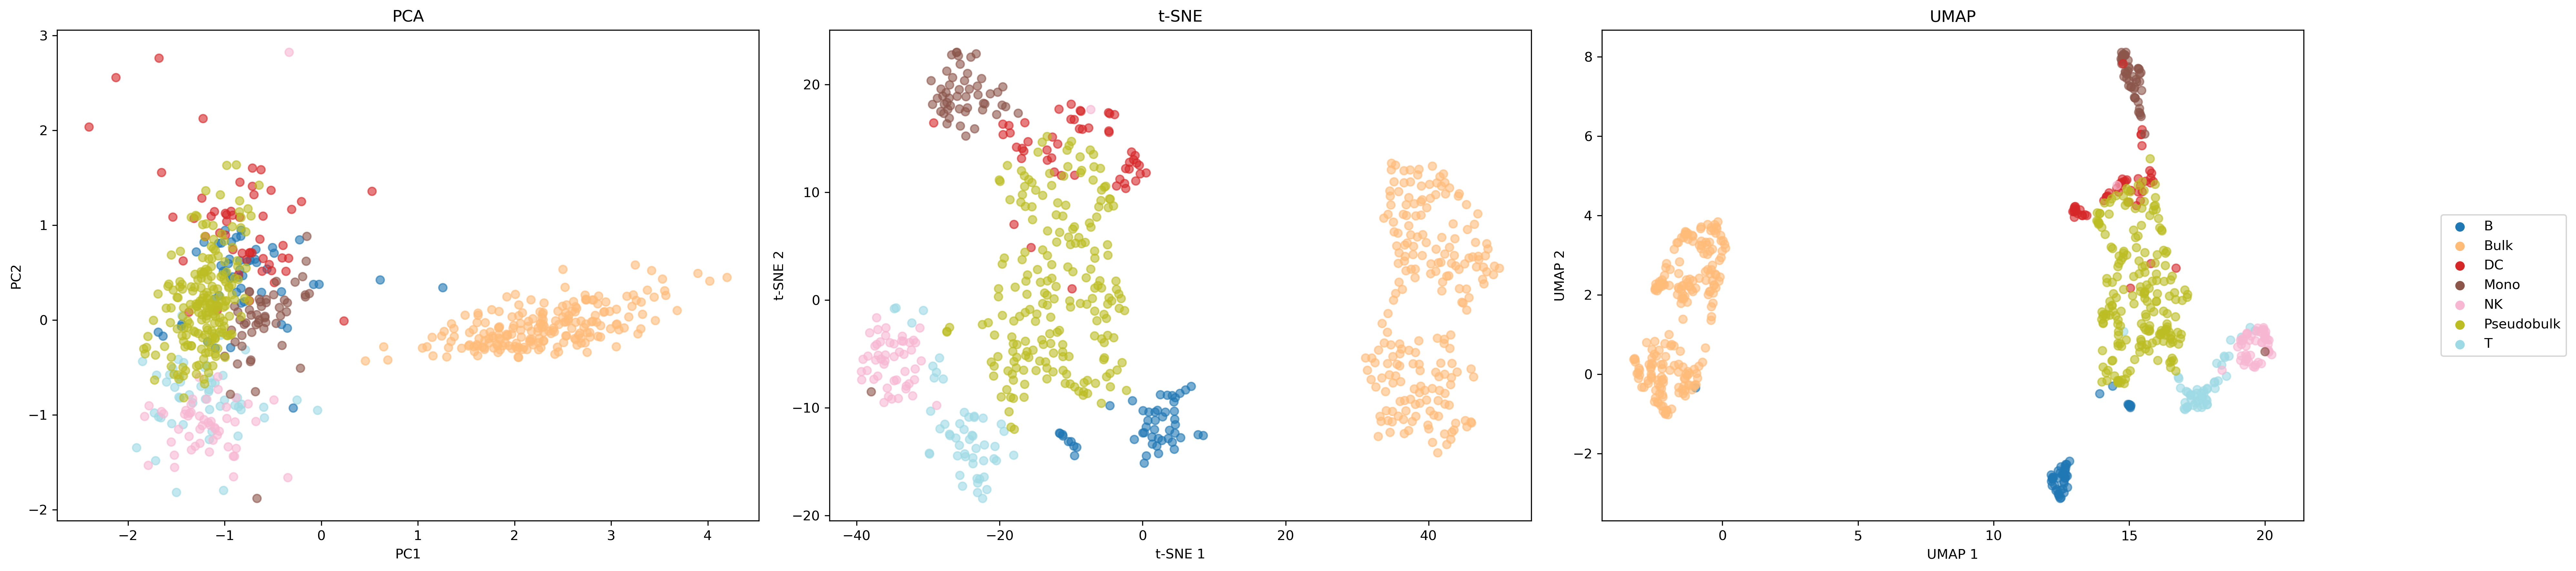

In [75]:
plt.figure(figsize=(24, 6), dpi=300)

# Create a color map for unique labels
unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))
point_colors = np.array([color_dict[label] for label in labels])

# Plot PCA
plt.subplot(131)
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=point_colors, alpha=0.6)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Plot t-SNE
plt.subplot(132)
plt.scatter(latent_2d_tsne[:, 0], latent_2d_tsne[:, 1], c=point_colors, alpha=0.6)
plt.title('t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot UMAP
plt.subplot(133)
plt.scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], c=point_colors, alpha=0.6)
plt.title('UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Add legend
legend_elements = [plt.scatter([], [], c=[color_dict[label]], label=label) for label in unique_labels]
plt.figlegend(handles=legend_elements, labels=list(unique_labels), bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()

## MixUpVI -> MixUpVI_v2

Here we use the MixUpVI model as base model for our 2 steps.

In [1]:
from benchmark_utils.training_utils import fit_mixupvi_v2
from benchmark_utils import preprocess_scrna, add_cell_types_grouped

In [2]:
import pickle as pkl


with open("project/highest_r2_genes_FACS_1st_gran.pkl", "rb") as f:
    filtered_genes = pkl.load(f)


In [3]:
import scanpy as sc

In [4]:
cti_adata = sc.read("/home/owkin/project/cti/cti_adata.h5ad")
cti_adata = preprocess_scrna(cti_adata, keep_genes=None)
cell_type = f"cell_types_grouped_FACS_1st_level_granularity"
cti_adata, train_test_index = add_cell_types_grouped(cti_adata, "FACS_1st_level_granularity")
cti_adata.obs["cell_types_grouped"] = cti_adata.obs[cell_type]
cti_adata = cti_adata[train_test_index["Train index"]]
cti_adata = cti_adata[:, filtered_genes]

In [5]:
new_model = fit_mixupvi_v2(cti_adata, "project/base_mixupvi_FACS_1st_gran", "project/mixupvi_v2_FACS_1st_gran_mixup_base", cell_type_group="cell_types_grouped", save_model=True)

2025-07-15 13:09:00.205 | WARNING  | benchmark_utils.training_utils:fit_mixupvi_v2:214 - Fictional categorical covariate inserted to initialize the parameters that are then used in the MixUpVI_v2 model, please remove it if you want to initialize the second network from scratch
2025-07-15 13:09:07.909 | INFO     | benchmark_utils.training_utils:fit_mixupvi_v2:219 - Base model fitted, saved in path:project/base_mixupvi_FACS_1st_gran, loading MixUpVI...


INFO     File project/base_mixupvi_FACS_1st_gran/model.pt already downloaded                                       


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

Anndata setup with scvi-tools version 1.0.0.

...

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['source'] │ pseudobulk │          0          │
│                     │    bulk    │          1          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 100/100: 100%|██████████| 100/100 [19:11<00:00, 11.07s/it, v_num=1, train_loss_step=2.95e+3, train_loss_epoch=2.91e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [19:11<00:00, 11.52s/it, v_num=1, train_loss_step=2.95e+3, train_loss_epoch=2.91e+3]


In [7]:
import scvi

In [8]:
base_model = scvi.model.MixUpVI.load("project/base_mixupvi_FACS_1st_gran", cti_adata.copy())

INFO     File project/base_mixupvi_FACS_1st_gran/model.pt already downloaded                                       


In [12]:
import numpy as np

n_cells_per_type = 50 # Number of cells to sample from each type
cell_types = cti_adata.obs[cell_type].unique()

sampled_indices = []
for ct in cell_types:
    ct_indices = cti_adata.obs[cti_adata.obs[cell_type] == ct].index
    if len(ct_indices) >= n_cells_per_type:
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=False)
    else:
        # If not enough cells, sample with replacement
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=True)
    sampled_indices.extend(sampled)

small_sc_dataset = cti_adata[sampled_indices].copy()

In [13]:
small_sc_dataset.obs["source"] = "pseudobulk"
small_sc_dataset.obsm["ground_truth"] = np.empty((len(small_sc_dataset), 5))

In [47]:
latent_sc = new_model.get_latent_representation(small_sc_dataset)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [33]:
latent_pseudobulk = new_model.get_latent_representation(adata[adata.obs["source"] == "pseudobulk"])
latent_bulk = new_model.get_latent_representation(adata[adata.obs["source"] == "bulk"])

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [36]:
latent_signature = new_model.module.latent_signature_matrix

In [48]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt


all_latent = np.concatenate([
    latent_sc,
    latent_pseudobulk,
    latent_bulk,
    latent_signature,
])

labels = np.concatenate([
    small_sc_dataset.obs["cell_types_grouped"],
    np.array(["Pseudobulk"]*len(latent_pseudobulk)),
    np.array(["Bulk"]*len(latent_bulk)),
    bulk_adata.uns["cell_types_order"],
    #[f"Signature {type}" for type in bulk_adata.uns["cell_types_order"]],
])


pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

latent_2d_pca = pca.fit_transform(all_latent)
latent_2d_tsne = tsne.fit_transform(all_latent)
latent_2d_umap = umap.fit_transform(all_latent)

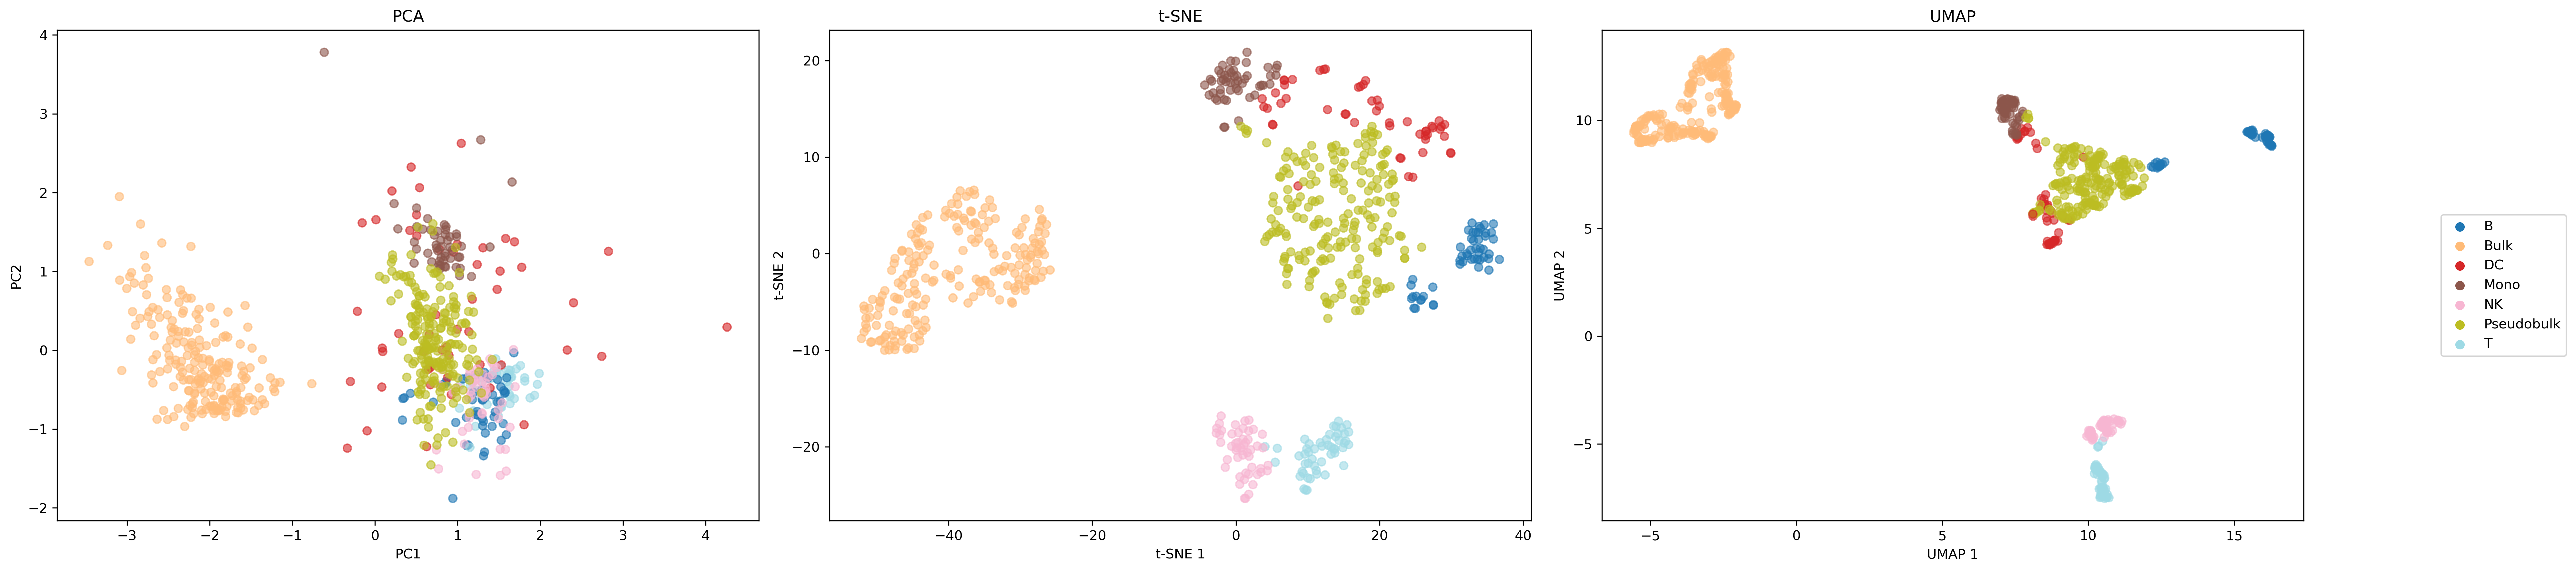

In [49]:
plt.figure(figsize=(24, 6), dpi=300)

# Create a color map for unique labels
unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))
point_colors = np.array([color_dict[label] for label in labels])

# Plot PCA
plt.subplot(131)
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=point_colors, alpha=0.6)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Plot t-SNE
plt.subplot(132)
plt.scatter(latent_2d_tsne[:, 0], latent_2d_tsne[:, 1], c=point_colors, alpha=0.6)
plt.title('t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot UMAP
plt.subplot(133)
plt.scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], c=point_colors, alpha=0.6)
plt.title('UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Add legend
legend_elements = [plt.scatter([], [], c=[color_dict[label]], label=label) for label in unique_labels]
plt.figlegend(handles=legend_elements, labels=list(unique_labels), bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()

## Modeling "Pseudobulks" and "Bulks" as batch effects

In [5]:
import scvi
from benchmark_utils.pseudobulk_dataset_utils import prepare_mixupvi_v2_data

In [6]:
base_model = scvi.model.MixUpVI.load("project/base_mixupvi_FACS_1st_gran_batch", cti_adata.copy())

INFO     File project/base_mixupvi_FACS_1st_gran_batch/model.pt already downloaded                                 


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [7]:
final_adata = prepare_mixupvi_v2_data(cti_adata, base_model, n_pseudobulk_samples=200)

In [8]:
cti_adata.obs.shape

(144607, 25)

In [9]:
final_adata.obs

,has_latent,source
PB_0,True,pseudobulk
PB_1,True,pseudobulk
PB_2,True,pseudobulk
PB_3,True,pseudobulk
PB_4,True,pseudobulk
...,...,...
201,False,bulk
202,False,bulk
203,False,bulk
204,False,bulk


In [20]:
cti_adata.obsm["latent_sc"] = base_model.get_latent_representation(give_mean=True, return_dist=False)

In [10]:
new_model = scvi.model.MixUpVI_v2.load("project/mixupvi_v2_FACS_1st_gran_mixup_base_batch_extra_alignment", final_adata)

INFO     File project/mixupvi_v2_FACS_1st_gran_mixup_base_batch_extra_alignment/model.pt already downloaded        


In [24]:
latent_sc = new_model.get_latent_representation(small_sc_dataset)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [15]:
latent_pseudobulk = new_model.get_latent_representation(final_adata[final_adata.obs["source"] == "pseudobulk"])
latent_bulk = new_model.get_latent_representation(final_adata[final_adata.obs["source"] == "bulk"])

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [16]:
latent_signature = new_model.module.latent_signature_matrix


In [17]:
final_adata.uns.keys()

odict_keys(['bulk_cell_types_order', '_scvi_uuid', '_scvi_manager_uuid'])

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt


all_latent = np.concatenate([
    latent_sc,
    latent_pseudobulk,
    latent_bulk,
    latent_signature,
])

labels = np.concatenate([
    small_sc_dataset.obs["cell_types_grouped"],
    np.array(["Pseudobulk"]*len(latent_pseudobulk)),
    np.array(["Bulk"]*len(latent_bulk)),
    final_adata.uns["bulk_cell_types_order"],
    #[f"Signature {type}" for type in bulk_adata.uns["cell_types_order"]],
])


pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

latent_2d_pca = pca.fit_transform(all_latent)
latent_2d_tsne = tsne.fit_transform(all_latent)
latent_2d_umap = umap.fit_transform(all_latent)

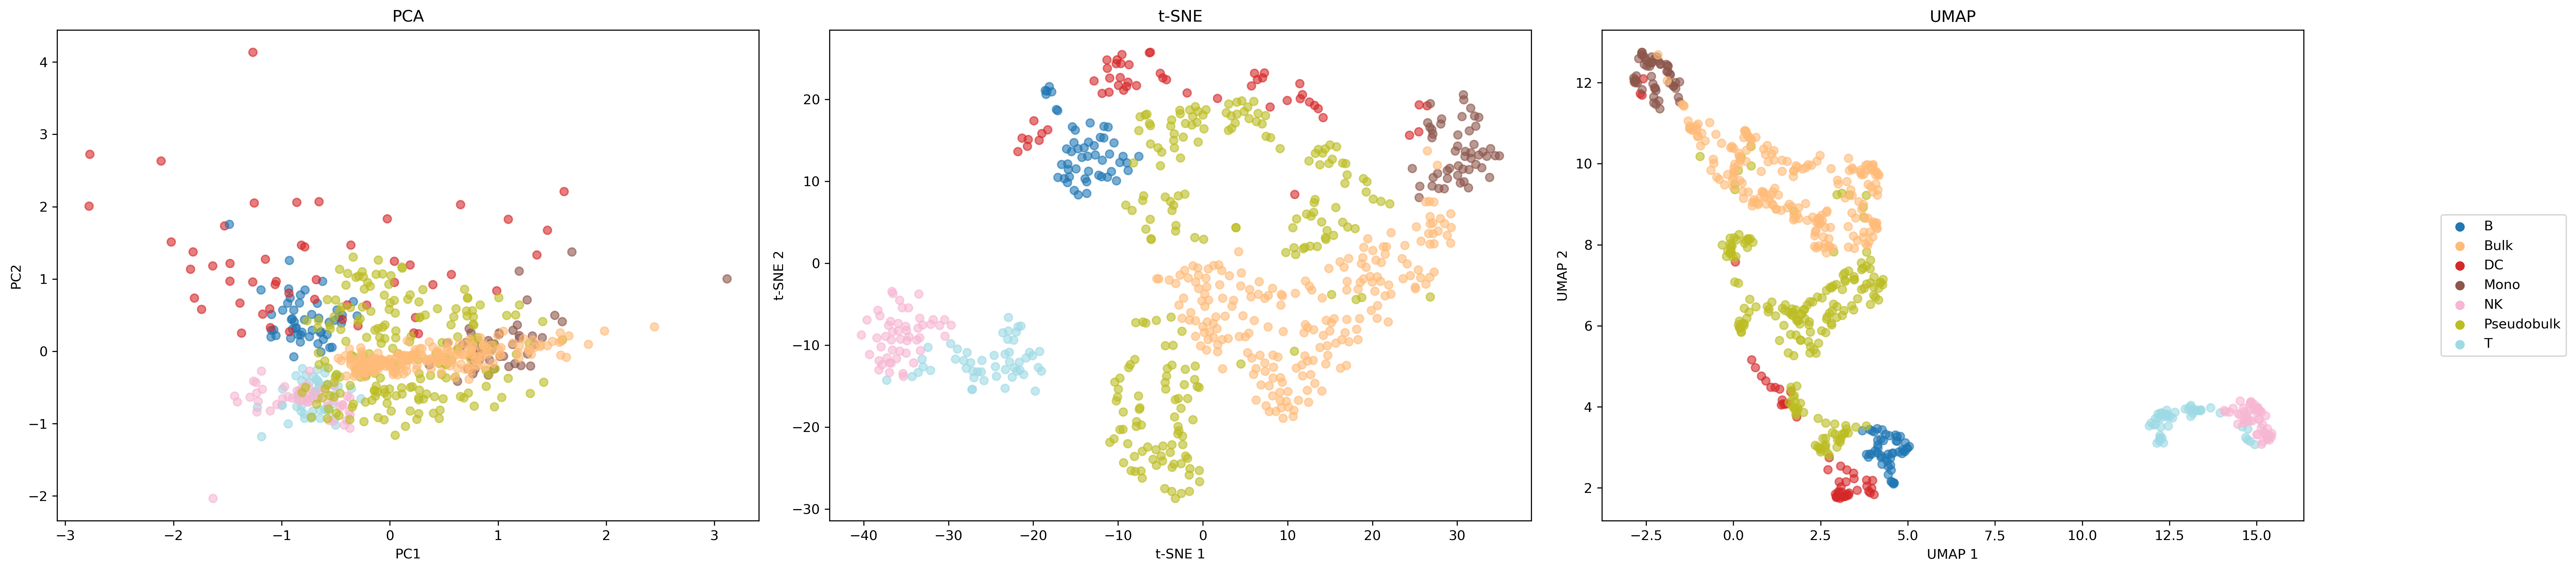

In [26]:
plt.figure(figsize=(24, 6), dpi=300)

# Create a color map for unique labels
unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))
point_colors = np.array([color_dict[label] for label in labels])

# Plot PCA
plt.subplot(131)
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=point_colors, alpha=0.6)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Plot t-SNE
plt.subplot(132)
plt.scatter(latent_2d_tsne[:, 0], latent_2d_tsne[:, 1], c=point_colors, alpha=0.6)
plt.title('t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot UMAP
plt.subplot(133)
plt.scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], c=point_colors, alpha=0.6)
plt.title('UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Add legend
legend_elements = [plt.scatter([], [], c=[color_dict[label]], label=label) for label in unique_labels]
plt.figlegend(handles=legend_elements, labels=list(unique_labels), bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()